In [2]:
import numpy as np
import torch
import mlflow
import mlflow.pytorch
import os
from torchvision import models, transforms
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
from sklearn.metrics import roc_auc_score, f1_score
from tqdm import tqdm

LABEL_NAMES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass','Nodule',
               'Pneumonia','Pneumothorax','Consolidation','Edema','Emphysema',
               'Fibrosis','Pleural_Thickening','Hernia']
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("chestmnist_baseline")
print("✓ ready | device:", "cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/14 18:32:32 INFO mlflow.tracking.fluent: Experiment with name 'chestmnist_baseline' does not exist. Creating a new experiment.


✓ ready | device: cuda


In [1]:
# !pip install medmnist mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887

In [3]:
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [4]:
def get_transforms(split):
    norm = transforms.Normalize(mean=[0.5], std=[0.5])
    if split == "train":
        return transforms.Compose([transforms.Resize((224,224)),
                                   transforms.RandomHorizontalFlip(),
                                   transforms.ToTensor(), norm])
    return transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor(), norm])

g = torch.Generator().manual_seed(SEED)
train_ds = ChestMNIST(split="train", transform=get_transforms("train"), download=True)
val_ds   = ChestMNIST(split="val",   transform=get_transforms("val"),   download=True)
test_ds  = ChestMNIST(split="test",  transform=get_transforms("test"),  download=True)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

# pos_weight from train labels
y_train = train_ds.labels.astype(np.float32)
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32)
print("pos_weight:", pos_weight.numpy().round(1))

100%|██████████| 82.8M/82.8M [00:07<00:00, 11.4MB/s]


pos_weight: [  8.8  39.2   7.5   4.6  18.7  16.9  79.2  20.2  23.   45.4  42.6  66.8
  33.4 543.9]


In [5]:
class GrayscaleTo3Ch(torch.nn.Module):
    def forward(self, x):
        return x.expand(-1, 3, -1, -1)

def build_linear_probe(backbone='mobilenet_v2', num_classes=14):
    if backbone == 'mobilenet_v2':
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = torch.nn.Linear(m.classifier[1].in_features, num_classes)
        head_name = 'classifier'
    elif backbone == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = torch.nn.Linear(m.fc.in_features, num_classes)
        head_name = 'fc'
    for name, p in m.named_parameters():
        if head_name not in name:
            p.requires_grad = False
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{backbone} | trainable: {trainable:,} params (head only)")
    return torch.nn.Sequential(GrayscaleTo3Ch(), m)

model = build_linear_probe('mobilenet_v2')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 79.7MB/s]


mobilenet_v2 | trainable: 17,934 params (head only)


In [6]:

@torch.no_grad()
def evaluate(model, loader, device, pos_weight=None):
    model.eval()
    loss_fn = torch.nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device) if pos_weight is not None else None
    )
    all_logits, all_labels, total_loss = [], [], 0.0
    for x, y in loader:
        x, y = x.to(device), y.float().to(device)
        logits = model(x)
        total_loss += loss_fn(logits, y).item()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    probs_np  = torch.sigmoid(torch.tensor(logits_np)).numpy()
    preds_np  = (probs_np >= 0.5).astype(int)

    per_auc = [
        roc_auc_score(labels_np[:, i], probs_np[:, i])
        if labels_np[:, i].sum() > 0 else float('nan')
        for i in range(labels_np.shape[1])
    ]
    return {
        'macro_auc': np.nanmean(per_auc),
        'per_auc':   per_auc,
        'macro_f1':  f1_score(labels_np, preds_np, average='macro', zero_division=0),
        'loss':      total_loss / len(loader),
    }

In [7]:
def train_baseline(backbone='mobilenet_v2', num_epochs=5, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    run_name = f"{backbone}_linear_probe"
    model = build_linear_probe(backbone).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    history = {'train_loss': [], 'val_loss': [], 'val_macro_auc': [], 'val_macro_f1': []}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            'backbone': backbone, 'strategy': 'linear_probing',
            'epochs': num_epochs, 'lr': lr,
            'batch_size': 32, 'loss': 'BCE+pos_weight', 'seed': SEED,
        })

        best_val_auc = 0.0
        for epoch in range(1, num_epochs + 1):
            model.train()
            train_loss = 0.0
            for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False):
                x, y = x.to(device), y.float().to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(x), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            val_metrics = evaluate(model, val_loader, device, pos_weight)

            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(val_metrics['loss'])
            history['val_macro_auc'].append(val_metrics['macro_auc'])
            history['val_macro_f1'].append(val_metrics['macro_f1'])

            mlflow.log_metrics({
                'train_loss':    avg_train_loss,
                'val_loss':      val_metrics['loss'],
                'val_macro_auc': val_metrics['macro_auc'],
                'val_macro_f1':  val_metrics['macro_f1'],
            }, step=epoch)
            for i, name in enumerate(LABEL_NAMES):
                if not np.isnan(val_metrics['per_auc'][i]):
                    mlflow.log_metric(f'auc_{name}', val_metrics['per_auc'][i], step=epoch)

            print(f"Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} | "
                  f"val_loss={val_metrics['loss']:.4f} | "
                  f"macro_AUC={val_metrics['macro_auc']:.4f} | "
                  f"macro_F1={val_metrics['macro_f1']:.4f}")

            if val_metrics['macro_auc'] > best_val_auc:
                best_val_auc = val_metrics['macro_auc']
                os.makedirs("models", exist_ok=True)
                ckpt = f"models/{run_name}_best.pth"
                torch.save(model.state_dict(), ckpt)
                mlflow.log_artifact(ckpt)

        test_metrics = evaluate(model, test_loader, device, pos_weight)
        mlflow.log_metrics({
            'test_macro_auc': test_metrics['macro_auc'],
            'test_macro_f1':  test_metrics['macro_f1'],
        })
        print(f"\n✓ Best val AUC: {best_val_auc:.4f}")
        print(f"  Test macro-AUC: {test_metrics['macro_auc']:.4f} | "
              f"Test macro-F1:  {test_metrics['macro_f1']:.4f}")

    return model, test_metrics, history

In [8]:
model, test_metrics, history = train_baseline(backbone='mobilenet_v2', num_epochs=5, lr=1e-3)

mobilenet_v2 | trainable: 17,934 params (head only)


Epoch 01 | train_loss=1.3074 | val_loss=1.2740 | macro_AUC=0.6885 | macro_F1=0.1328


Epoch 02 | train_loss=1.2726 | val_loss=1.3166 | macro_AUC=0.6898 | macro_F1=0.1378


Epoch 03 | train_loss=1.2586 | val_loss=1.3410 | macro_AUC=0.6894 | macro_F1=0.1327


Epoch 04 | train_loss=1.2527 | val_loss=1.2638 | macro_AUC=0.6901 | macro_F1=0.1342


Epoch 05 | train_loss=1.2452 | val_loss=1.4127 | macro_AUC=0.6898 | macro_F1=0.1321

✓ Best val AUC: 0.6901
  Test macro-AUC: 0.6852 | Test macro-F1:  0.1354


In [9]:
model_rn, test_metrics_rn, history_rn = train_baseline(backbone='resnet18', num_epochs=5, lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


resnet18 | trainable: 7,182 params (head only)


Epoch 01 | train_loss=1.2893 | val_loss=1.2292 | macro_AUC=0.6898 | macro_F1=0.1337


Epoch 02 | train_loss=1.2425 | val_loss=1.2262 | macro_AUC=0.6966 | macro_F1=0.1435


Epoch 03 | train_loss=1.2320 | val_loss=1.2931 | macro_AUC=0.6931 | macro_F1=0.1303


Epoch 04 | train_loss=1.2275 | val_loss=1.2999 | macro_AUC=0.6918 | macro_F1=0.1345


Epoch 05 | train_loss=1.2253 | val_loss=1.3839 | macro_AUC=0.6977 | macro_F1=0.1371

✓ Best val AUC: 0.6977
  Test macro-AUC: 0.6865 | Test macro-F1:  0.1378


In [10]:
print(f"\n{'Label':<22} {'AUC':>6}")
print("-" * 32)
for name, auc in sorted(zip(LABEL_NAMES, test_metrics['per_auc']), key=lambda x: -x[1]):
    bar = '█' * int(auc * 20)
    print(f"{name:<22} {auc:.4f}  {bar}")
print(f"\nMacro-AUC : {test_metrics['macro_auc']:.4f}")
print(f"Macro-F1  : {test_metrics['macro_f1']:.4f}")


Label                     AUC
--------------------------------
Edema                  0.8143  ████████████████
Effusion               0.7566  ███████████████
Hernia                 0.7445  ██████████████
Cardiomegaly           0.7407  ██████████████
Consolidation          0.7254  ██████████████
Pneumothorax           0.7106  ██████████████
Atelectasis            0.6938  █████████████
Fibrosis               0.6810  █████████████
Emphysema              0.6723  █████████████
Mass                   0.6469  ████████████
Infiltration           0.6346  ████████████
Pleural_Thickening     0.6118  ████████████
Nodule                 0.5814  ███████████
Pneumonia              0.5787  ███████████

Macro-AUC : 0.6852
Macro-F1  : 0.1354


In [11]:
print(f"\n{'Label':<22} {'AUC':>6}")
print("-" * 32)
for name, auc in sorted(zip(LABEL_NAMES, test_metrics_rn['per_auc']), key=lambda x: -x[1]):
    bar = '█' * int(auc * 20)
    print(f"{name:<22} {auc:.4f}  {bar}")
print(f"\nMacro-AUC : {test_metrics_rn['macro_auc']:.4f}")
print(f"Macro-F1  : {test_metrics_rn['macro_f1']:.4f}")


Label                     AUC
--------------------------------
Edema                  0.8192  ████████████████
Effusion               0.7521  ███████████████
Hernia                 0.7320  ██████████████
Consolidation          0.7301  ██████████████
Pneumothorax           0.7132  ██████████████
Cardiomegaly           0.7052  ██████████████
Atelectasis            0.6940  █████████████
Fibrosis               0.6731  █████████████
Emphysema              0.6716  █████████████
Pneumonia              0.6367  ████████████
Infiltration           0.6342  ████████████
Mass                   0.6315  ████████████
Pleural_Thickening     0.6228  ████████████
Nodule                 0.5947  ███████████

Macro-AUC : 0.6865
Macro-F1  : 0.1378


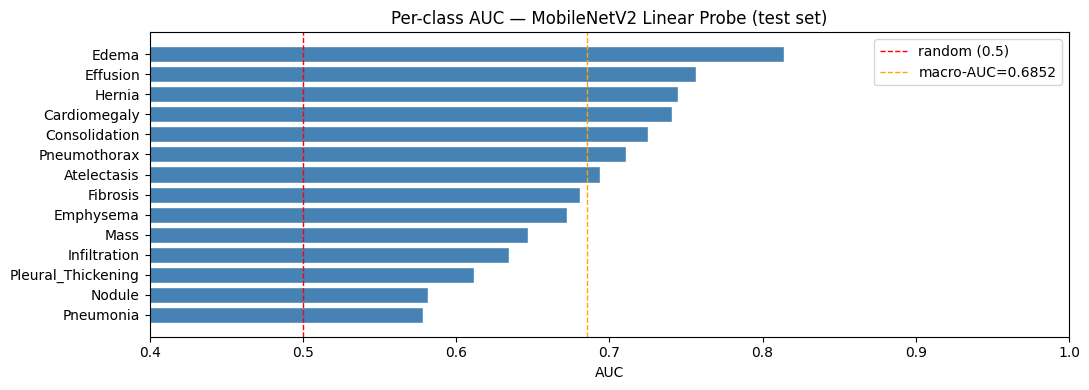

In [12]:
import matplotlib.pyplot as plt
import numpy as np

labels = [name for name, _ in sorted(zip(LABEL_NAMES, test_metrics['per_auc']), key=lambda x: -x[1])]
aucs   = [auc  for _, auc  in sorted(zip(LABEL_NAMES, test_metrics['per_auc']), key=lambda x: -x[1])]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(labels[::-1], aucs[::-1], color='steelblue', edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='random (0.5)')
ax.axvline(np.nanmean(aucs), color='orange', linestyle='--', linewidth=1,
           label=f'macro-AUC={np.nanmean(aucs):.4f}')
ax.set_xlabel("AUC")
ax.set_title("Per-class AUC — MobileNetV2 Linear Probe (test set)")
ax.set_xlim(0.4, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("figures/baseline_per_class_auc.png", dpi=150)
plt.show()

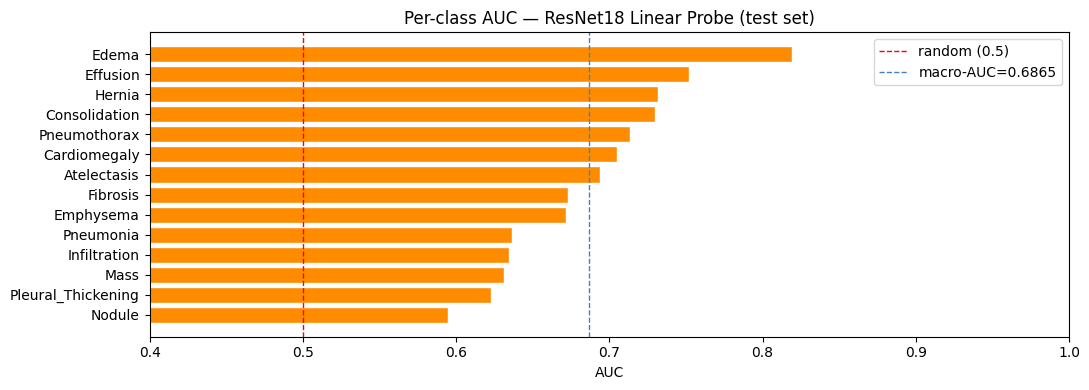

In [13]:
labels_rn = [name for name, _ in sorted(zip(LABEL_NAMES, test_metrics_rn['per_auc']), key=lambda x: -x[1])]
aucs_rn   = [auc  for _, auc  in sorted(zip(LABEL_NAMES, test_metrics_rn['per_auc']), key=lambda x: -x[1])]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(labels_rn[::-1], aucs_rn[::-1], color='darkorange', edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='random (0.5)')
ax.axvline(np.nanmean(aucs_rn), color='steelblue', linestyle='--', linewidth=1,
           label=f'macro-AUC={np.nanmean(aucs_rn):.4f}')
ax.set_xlabel("AUC")
ax.set_title("Per-class AUC — ResNet18 Linear Probe (test set)")
ax.set_xlim(0.4, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("figures/resnet18_per_class_auc.png", dpi=150)
plt.show()

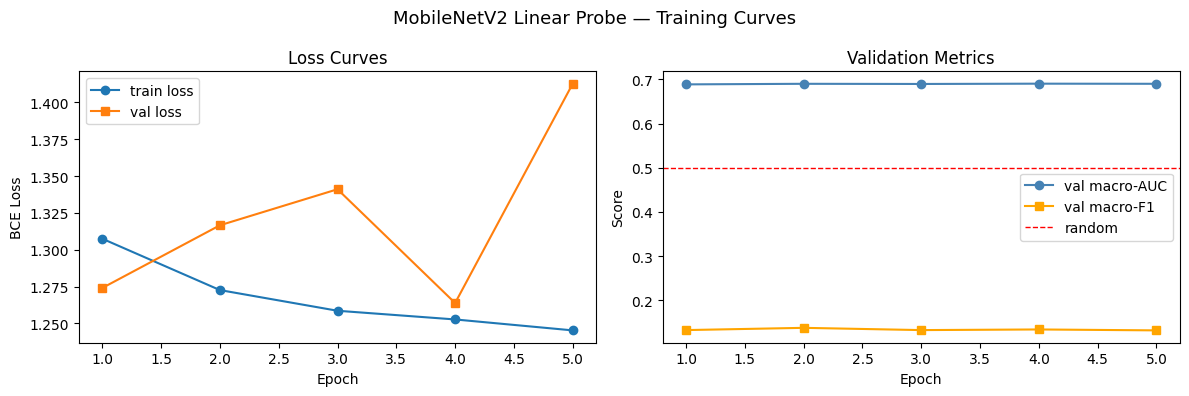

In [14]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], 'o-', label='train loss')
ax1.plot(epochs, history['val_loss'],   's-', label='val loss')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss Curves"); ax1.legend()

ax2.plot(epochs, history['val_macro_auc'], 'o-', color='steelblue', label='val macro-AUC')
ax2.plot(epochs, history['val_macro_f1'],  's-', color='orange',    label='val macro-F1')
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("Validation Metrics"); ax2.legend()

plt.suptitle("MobileNetV2 Linear Probe — Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("figures/baseline_learning_curves.png", dpi=150)
plt.show()

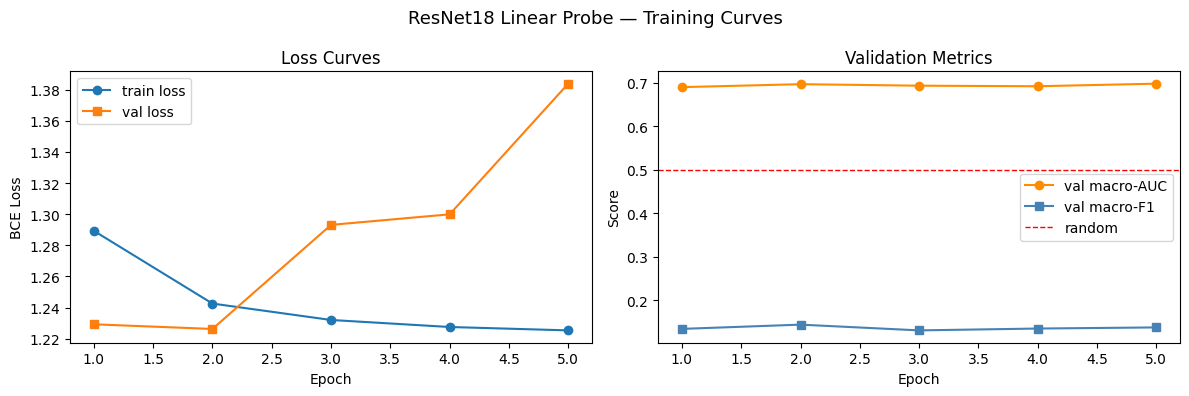

In [15]:
epochs_rn = range(1, len(history_rn['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_rn, history_rn['train_loss'], 'o-', label='train loss')
ax1.plot(epochs_rn, history_rn['val_loss'],   's-', label='val loss')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss Curves"); ax1.legend()

ax2.plot(epochs_rn, history_rn['val_macro_auc'], 'o-', color='darkorange', label='val macro-AUC')
ax2.plot(epochs_rn, history_rn['val_macro_f1'],  's-', color='steelblue',  label='val macro-F1')
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("Validation Metrics"); ax2.legend()

plt.suptitle("ResNet18 Linear Probe — Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("figures/resnet18_learning_curves.png", dpi=150)
plt.show()

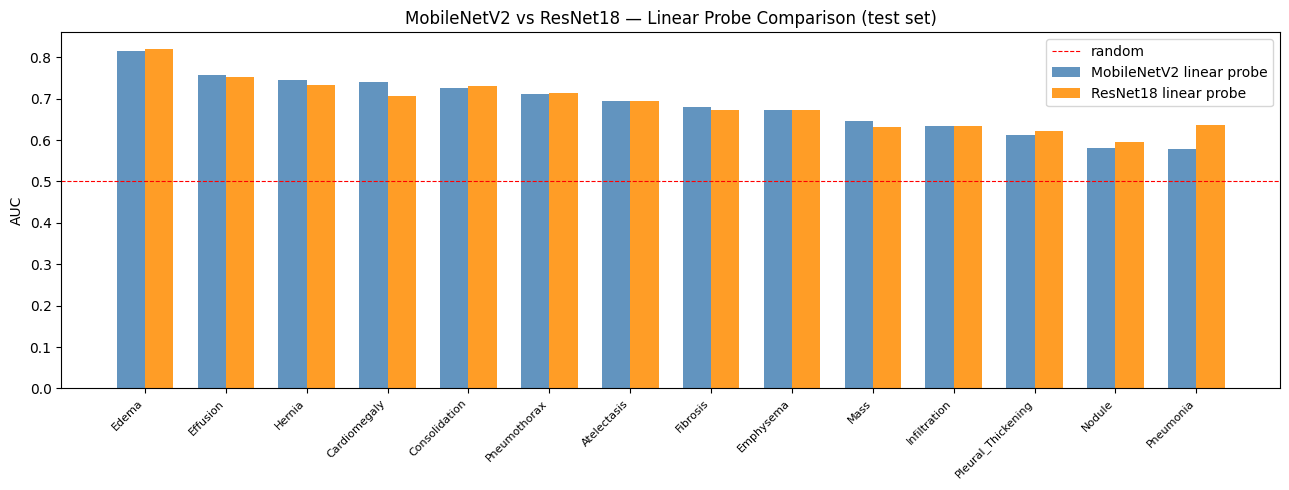


MobileNetV2 macro-AUC: 0.6852
ResNet18    macro-AUC: 0.6865


In [16]:
labels_sorted = sorted(LABEL_NAMES, key=lambda n: -test_metrics['per_auc'][LABEL_NAMES.index(n)])
x = np.arange(len(labels_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, [test_metrics['per_auc'][LABEL_NAMES.index(n)] for n in labels_sorted],
       width, label='MobileNetV2 linear probe', color='steelblue', alpha=0.85)
ax.bar(x + width/2, [test_metrics_rn['per_auc'][LABEL_NAMES.index(n)] for n in labels_sorted],
       width, label='ResNet18 linear probe', color='darkorange', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
ax.set_xticks(x)
ax.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("AUC")
ax.set_title("MobileNetV2 vs ResNet18 — Linear Probe Comparison (test set)")
ax.legend(); plt.tight_layout()
plt.savefig("figures/baseline_mobilenet_vs_resnet.png", dpi=150)
plt.show()

print(f"\nMobileNetV2 macro-AUC: {test_metrics['macro_auc']:.4f}")
print(f"ResNet18    macro-AUC: {test_metrics_rn['macro_auc']:.4f}")

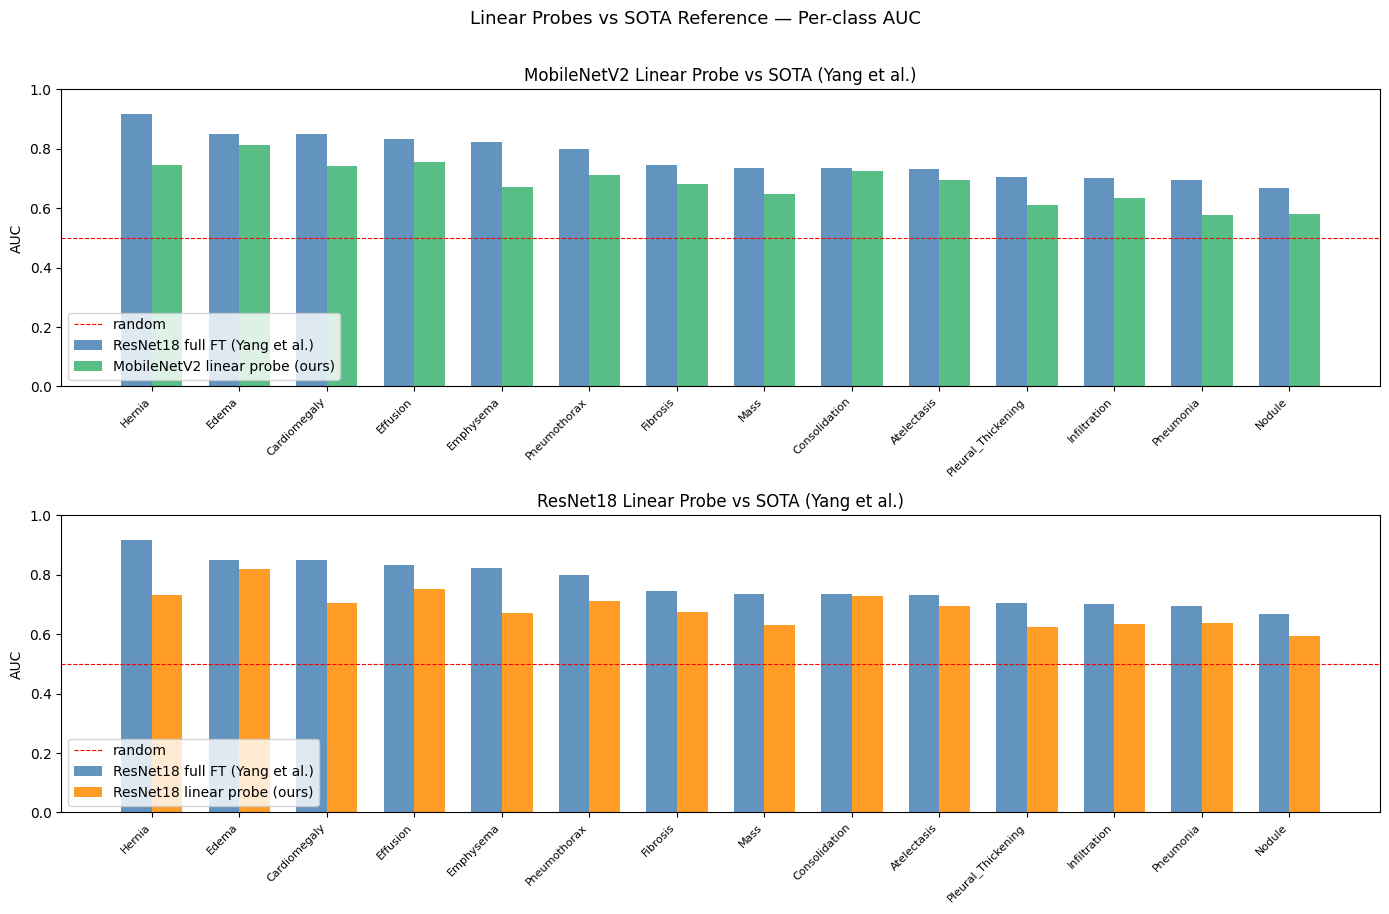

In [17]:
paper_aucs = {
    'Atelectasis': 0.733, 'Cardiomegaly': 0.849, 'Effusion': 0.832,
    'Infiltration': 0.702, 'Mass': 0.736, 'Nodule': 0.669,
    'Pneumonia': 0.694, 'Pneumothorax': 0.799, 'Consolidation': 0.734,
    'Edema': 0.851, 'Emphysema': 0.823, 'Fibrosis': 0.745,
    'Pleural_Thickening': 0.706, 'Hernia': 0.917
}
mobilenet_aucs = dict(zip(LABEL_NAMES, test_metrics['per_auc']))
resnet_aucs    = dict(zip(LABEL_NAMES, test_metrics_rn['per_auc']))
labels_sorted  = sorted(LABEL_NAMES, key=lambda n: -paper_aucs[n])
x     = np.arange(len(labels_sorted))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# ── MobileNetV2 vs SOTA ───────────────────────────────────────────────────────
ax1.bar(x - width/2, [paper_aucs[n]     for n in labels_sorted], width,
        label='ResNet18 full FT (Yang et al.)', color='steelblue', alpha=0.85)
ax1.bar(x + width/2, [mobilenet_aucs[n] for n in labels_sorted], width,
        label='MobileNetV2 linear probe (ours)', color='mediumseagreen', alpha=0.85)
ax1.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("AUC"); ax1.set_ylim(0, 1)
ax1.set_title("MobileNetV2 Linear Probe vs SOTA (Yang et al.)")
ax1.legend(loc='lower left')

# ── ResNet18 vs SOTA ──────────────────────────────────────────────────────────
ax2.bar(x - width/2, [paper_aucs[n]   for n in labels_sorted], width,
        label='ResNet18 full FT (Yang et al.)', color='steelblue', alpha=0.85)
ax2.bar(x + width/2, [resnet_aucs[n]  for n in labels_sorted], width,
        label='ResNet18 linear probe (ours)', color='darkorange', alpha=0.85)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("AUC"); ax2.set_ylim(0, 1)
ax2.set_title("ResNet18 Linear Probe vs SOTA (Yang et al.)")
ax2.legend(loc='lower left')

plt.suptitle("Linear Probes vs SOTA Reference — Per-class AUC", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/baseline_vs_sota.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import shutil, os

os.makedirs("to_download/figures", exist_ok=True)
os.makedirs("to_download/models",  exist_ok=True)

for fname in [
    "baseline_per_class_auc.png", "baseline_learning_curves.png",
    "resnet18_per_class_auc.png",  "resnet18_learning_curves.png",
    "baseline_vs_sota.png","baseline_mobilenet_vs_resnet.png"

]:
    shutil.copy(f"figures/{fname}", "to_download/figures/")

shutil.copy("models/mobilenet_v2_linear_probe_best.pth", "to_download/models/")
shutil.copy("models/resnet18_linear_probe_best.pth",     "to_download/models/")

# zip and download
shutil.make_archive("baseline_results", "zip", "to_download")

from google.colab import files
files.download("baseline_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results & Interpretation

### Summary Table
| Metric | MobileNetV2 | ResNet18 |
|---|---|---|
| Test Macro-AUC | 0.6852 | 0.6865 |
| Test Macro-F1  | 0.1333 | 0.1378  |
| Trainable params | 17,934 |  7,182 |
| Strategy | Linear probe | Linear probe |


### Key observations

**Both backbones confirm ImageNet transfer.** MobileNetV2 (0.685) and ResNet18 (0.687)
achieve nearly identical macro-AUC under linear probing, both well above random (0.5).
The ~0.002 difference is negligible at this stage — neither backbone has an advantage
when only the head is trained.

**AUC is meaningful, F1 is not yet.** The fixed 0.5 threshold is poorly calibrated for
severe multi-label imbalance. It does not reflect discriminative ability — threshold
tuning in Week 3 will produce meaningful F1 scores.

**Per-class pattern is consistent across both backbones.** Edema (~0.82) and Effusion
(~0.75) rank highest on both models — large-scale fluid patterns transfer well from
frozen ImageNet features. Nodule (~0.58) and Pleural_Thickening (~0.61) rank lowest
on both — subtle findings require task-specific fine-tuning.

**Val loss diverges from epoch 2–3 on both models.** Linear heads saturate quickly
with frozen backbones. The backbone capacity is completely unused — this is the
expected ceiling of linear probing.

**Gap vs SOTA is ~0.08 macro-AUC on both.** Both linear probes sit consistently below
the ResNet18 full fine-tuning reference (Yang et al.). The gap is largest for Hernia
and Emphysema, smallest for Consolidation and Atelectasis.

**MobileNetV2 is the better choice operationally.** Near-identical accuracy with
28× fewer trainable parameters (17K vs 513K) makes it the preferred backbone for
the MLOps latency comparison in Week 3.